## Laplace filter analysis of two-point functions
This notebook reproduces the findings of [*Application of Laplace filters to the analysis of lattice time correlators*, A Portelli and J T Tsang, Phys. Rev. D 112(9), 2025](https://doi.org/10.1103/3v93-9s9t).

In [ ]:
import os
import latan
import numpy as np
import numpy.typing as npt
import latan.datasets.arXiv_2508_11541 as lf_paper
import matplotlib.pyplot as plt
from typing import Any, Dict, Optional, Tuple
from iminuit import Minuit

%matplotlib inline
%config InlineBackend.figure_format = "retina"

Download data

In [2]:
os.chdir(os.path.dirname(os.path.abspath("__file__")))
filename = lf_paper.download(".")

Data already downloaded


Load and bin all three two-point functions (M0M-mes-ll, F1M-mes-lh, and F1M-mes-hh)

In [3]:
data: Dict[str, npt.NDArray] = {}
names = ["M0M-mes-ll", "F1M-mes-lh", "F1M-mes-hh"]
bin_sizes = [32, 24, 24]
for name, bin_size in zip(names, bin_sizes):
    print(f"==== {name}")
    data[name] = lf_paper.load_correlator(filename, name, verbose=True)
    data[name] = lf_paper.bin_correlator(data[name], bin_size, verbose=True)


==== M0M-mes-ll
nConf: 82
 nSrc: 64
   nt: 128
 size: 5248
 nBin: 164
==== F1M-mes-lh
nConf: 72
 nSrc: 48
   nt: 96
 size: 3456
 nBin: 144
==== F1M-mes-hh
nConf: 72
 nSrc: 48
   nt: 96
 size: 3456
 nBin: 144


Plot correlation matrices and CDRs (cf. Figs. 2 & 3)

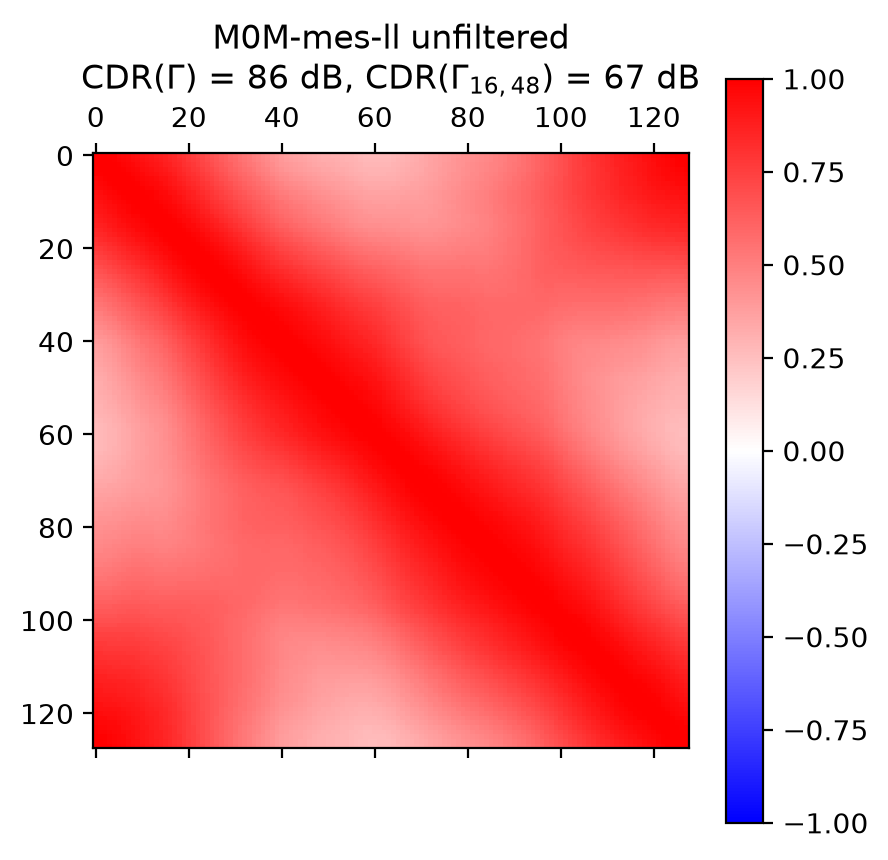

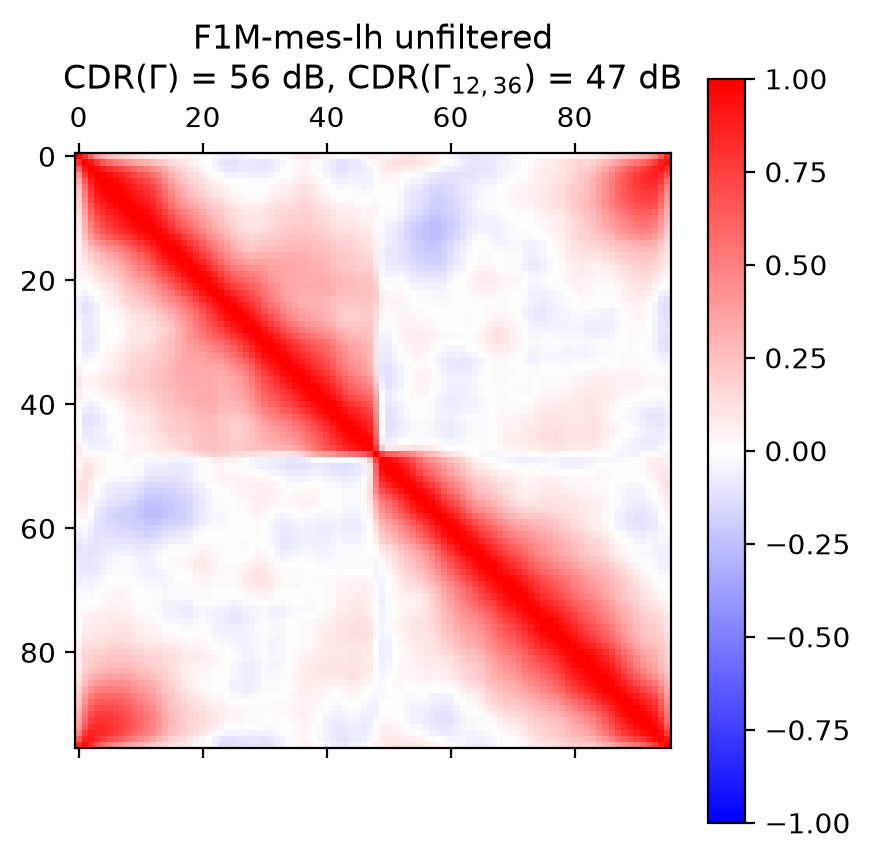

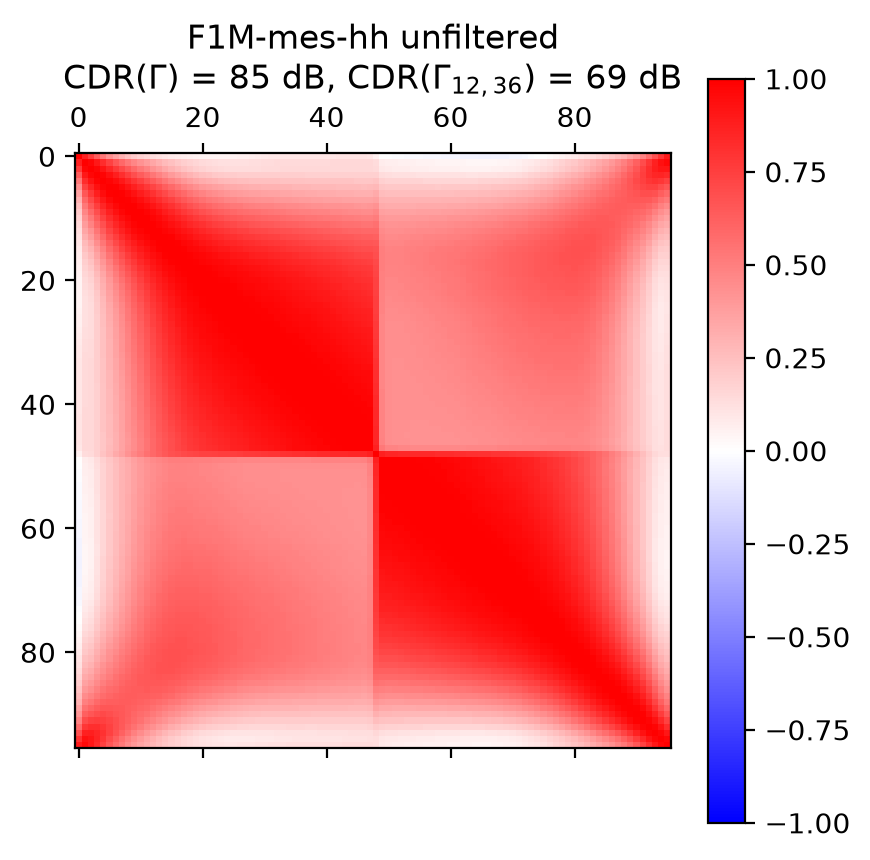

In [4]:
ranges = [(16, 48), (12, 36), (12, 36)]
for (name, corr), r in zip(data.items(), ranges):
    V = np.cov(corr, rowvar=False) / corr.shape[0]
    Gamma, _ = latan.var_to_corr(V)
    plt.matshow(Gamma, cmap="bwr", vmin=-1.0, vmax=1.0)
    title = f"{name} unfiltered\n"
    cdr = latan.cdr(Gamma)
    title += f"$\\mathrm{{CDR}}(\\Gamma)$ = {cdr:.0f} dB, "
    cdr = latan.cdr(Gamma[r[0] : r[1], r[0] : r[1]])
    title += f"$\\mathrm{{CDR}}(\\Gamma_{{{r[0]}, {r[1]}}})$ = {cdr:.0f} dB"
    plt.title(title)
    plt.colorbar()
    plt.show()

Plot the filtered CDRs as a function of the Laplace regulator (cf. Fig. 1)

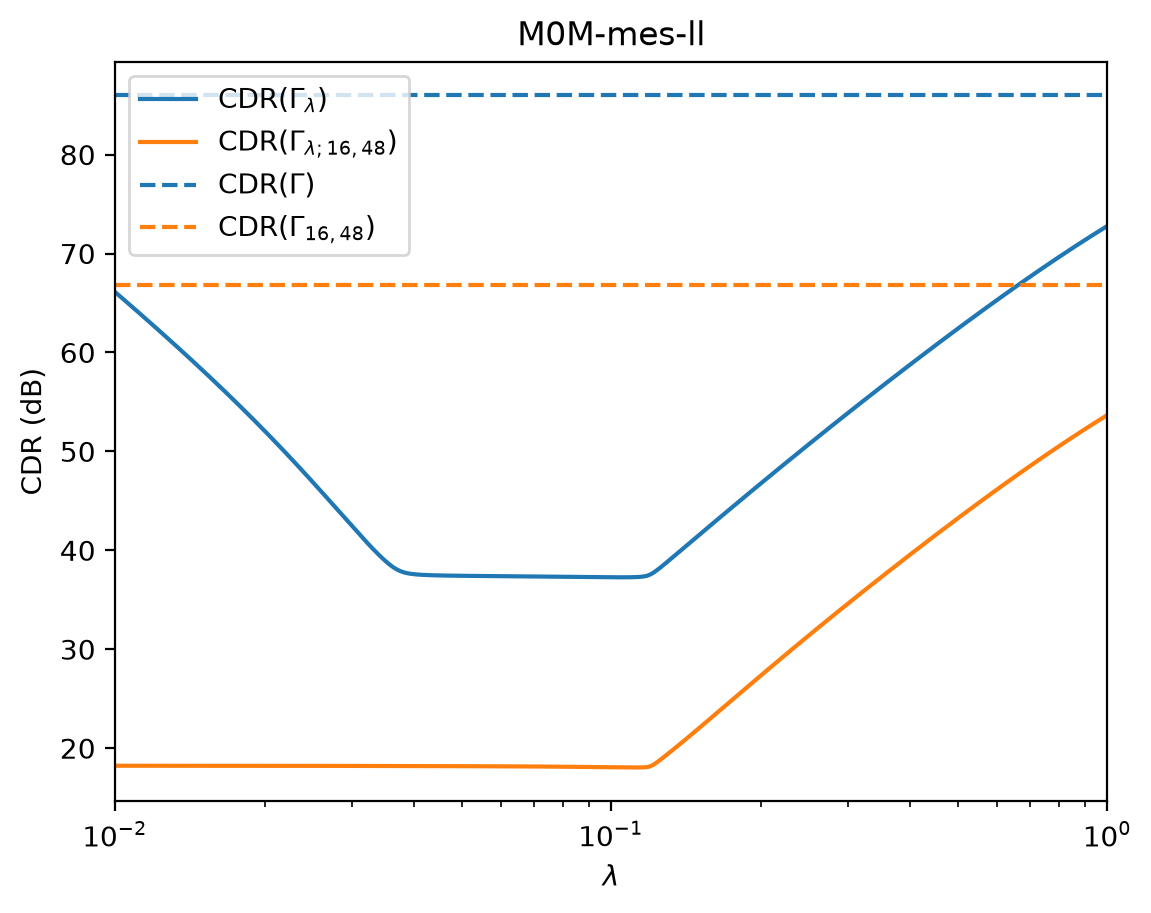

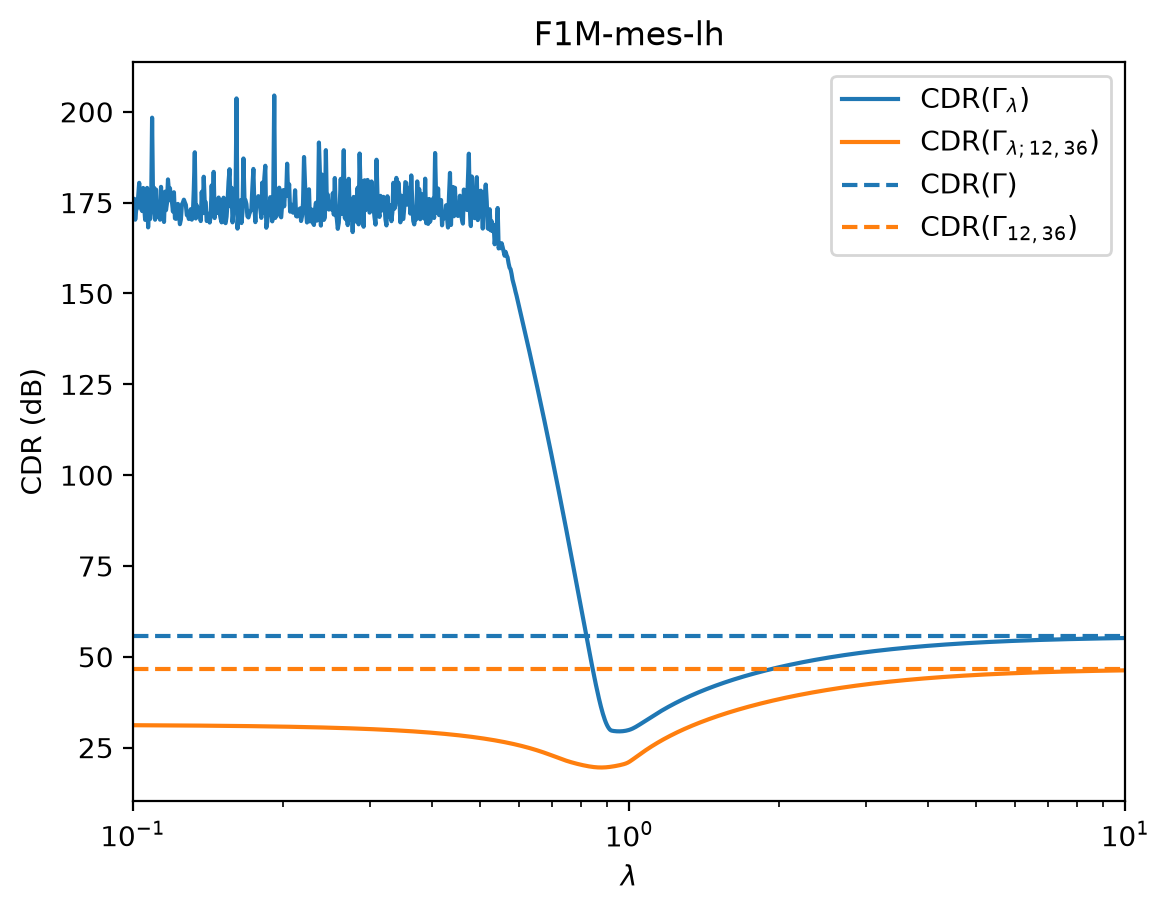

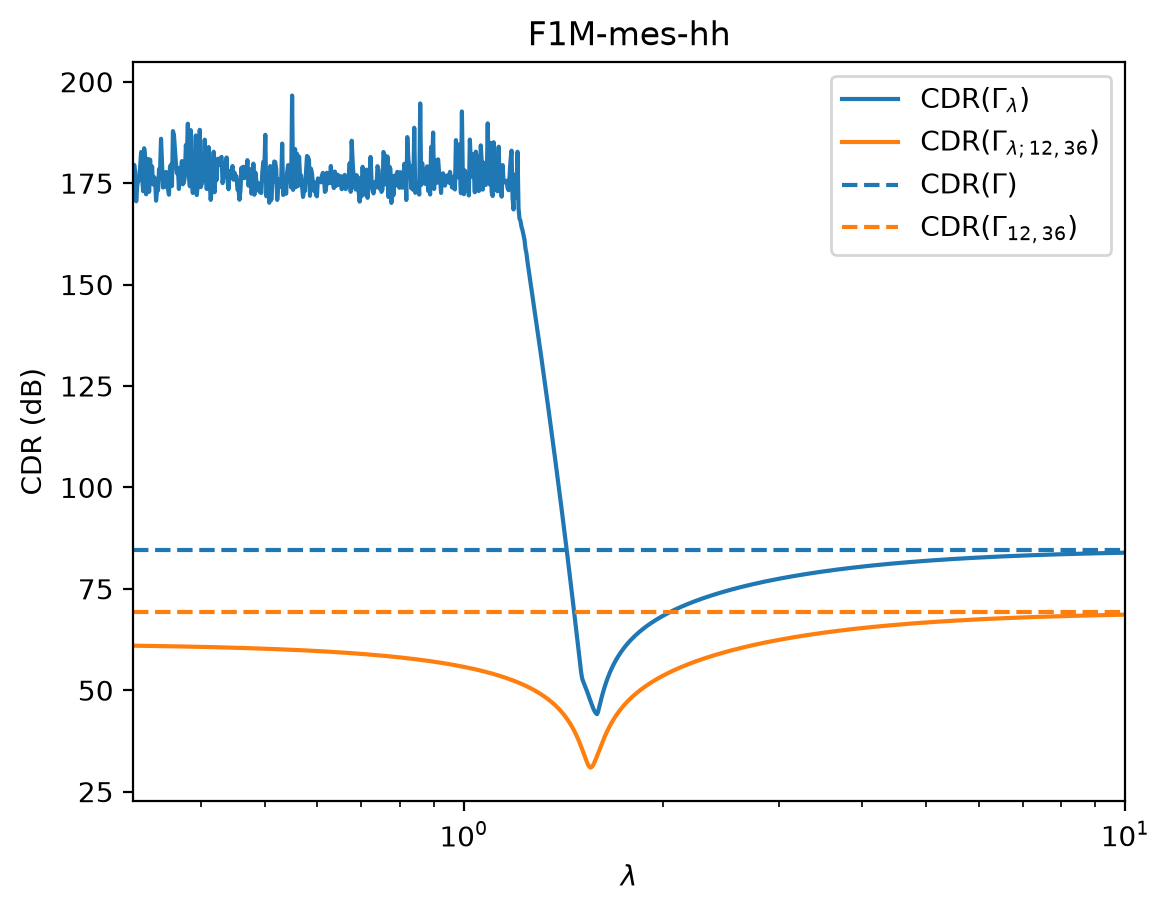

In [5]:
log_range = [(-2.0, 0.0), (-1.0, 1.0), (-0.5, 1.0)]
npts = 1000
for (name, corr), r, lr in zip(data.items(), ranges, log_range):
    V = np.cov(corr, rowvar=False) / corr.shape[0]
    Gamma, _ = latan.var_to_corr(V)
    cdr_ref = latan.cdr(Gamma)
    cdr_range_ref = latan.cdr(Gamma[r[0] : r[1], r[0] : r[1]])
    lambs = np.logspace(lr[0], lr[1], npts)
    cdr = np.empty(npts)
    cdr_range = np.empty(npts)
    for i in range(npts):
        Vf = latan.lfilter(V, lambs[i], dim=(0, 1))
        Gammaf, _ = latan.var_to_corr(Vf)
        cdr[i] = latan.cdr(Gammaf)
        cdr_range[i] = latan.cdr(Gammaf[r[0] : r[1], r[0] : r[1]])
    plt.plot(lambs, cdr, label=r"$\mathrm{CDR}(\Gamma_\lambda)$")
    plt.plot(
        lambs, cdr_range, label=rf"$\mathrm{{CDR}}(\Gamma_{{\lambda;{r[0]}, {r[1]}}})$"
    )
    plt.axhline(
        cdr_ref,
        0.0,
        lambs[-1],
        color="C0",
        linestyle="--",
        label=r"$\mathrm{CDR}(\Gamma)$",
    )
    plt.axhline(
        cdr_range_ref,
        0.0,
        lambs[-1],
        color="C1",
        linestyle="--",
        label=f"$\\mathrm{{CDR}}(\\Gamma_{{{r[0]}, {r[1]}}})$",
    )
    plt.xlim(lambs[0], lambs[-1])
    plt.xscale("log")
    plt.xlabel(r"$\lambda$")
    plt.ylabel(r"$\mathrm{CDR}~(\mathrm{dB})$")
    plt.legend()
    plt.title(name)
    plt.show()

In [42]:
from unittest import result


class Cdr:
    _var: npt.NDArray
    _varf: npt.NDArray
    _range: Optional[Tuple[int, int]]

    def __init__(
        self, var: npt.NDArray, range: Optional[Tuple[int, int]] = None
    ) -> None:
        self._var = var
        self._varf = np.zeros(var.shape)
        self._range = range

    def __call__(self, *args: Any) -> float:
        (lamb,) = args
        latan.lfilter(self._var, lamb, dim=(0, 1), out=self._varf)
        if self._range is None:
            return latan.cdr(latan.var_to_corr(self._varf)[0])
        else:
            Gamma, _ = latan.var_to_corr(self._varf)
            r = self._range
            return latan.cdr(Gamma[r[0] : r[1], r[0] : r[1]])


for (name, corr), r in zip(data.items(), ranges):
    print(f"==== {name}")
    V = np.cov(corr, rowvar=False) / corr.shape[0]
    cost = Cdr(V)
    m = Minuit(cost, 5.0, name=("lamb",))
    m.limits["lamb"] = (0.0, 5.0)
    res = m.migrad()
    print(f"global lambda_opt = {res.values['lamb']:.4f}")
    cost = Cdr(V, r)
    m = Minuit(cost, 5.0, name=("lamb",))
    m.limits["lamb"] = (0.0, 5.0)
    res = m.migrad()
    print(f" range lambda_opt = {res.values['lamb']:.4f}")


==== M0M-mes-ll
global lambda_opt = 0.1050
 range lambda_opt = 0.1115
==== F1M-mes-lh
global lambda_opt = 0.9528
 range lambda_opt = 0.8769
==== F1M-mes-hh
global lambda_opt = 1.5901
 range lambda_opt = 1.5543
